In [1]:
# Install required libraries
%pip install numpy pandas matplotlib scipy requests yfinance pyarrow jupyter

  Using cached numpy-2.4.4-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached scipy-1.17.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached yfinance-1.3.0-py2.py3-none-any.whl.metadata (6.1 kB)
  Using cached pyarrow-23.0.1-cp314-cp314-macosx_12_0_arm64.whl.metadata (3.1 kB)
  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-macosx_10_15_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (

## Phase 1

Fetching VIX data...


[*********************100%***********************]  1 of 1 completed


VIX records retrieved: 82

Found 13 files. Stitching together sequentially to protect memory...
 -> Reading download/spyususd-tick-2020-01-01-2020-01-31.csv
 -> Reading download/spyususd-tick-2020-02-01-2020-02-10.csv
 -> Reading download/spyususd-tick-2020-02-11-2020-02-20.csv
 -> Reading download/spyususd-tick-2020-02-21-2020-02-29.csv
 -> Reading download/spyususd-tick-2020-03-01-2020-03-05.csv
 -> Reading download/spyususd-tick-2020-03-06-2020-03-10.csv
 -> Reading download/spyususd-tick-2020-03-11-2020-03-15.csv
 -> Reading download/spyususd-tick-2020-03-16-2020-03-20.csv
 -> Reading download/spyususd-tick-2020-03-21-2020-03-25.csv
 -> Reading download/spyususd-tick-2020-03-26-2020-03-31.csv
 -> Reading download/spyususd-tick-2020-04-01-2020-04-10.csv
 -> Reading download/spyususd-tick-2020-04-11-2020-04-20.csv
 -> Reading download/spyususd-tick-2020-04-21-2020-04-30.csv

Concatenating all files into one DataFrame...
Loaded 11542453 total SPY ticks.
Dropped 0 simultaneous duplicat

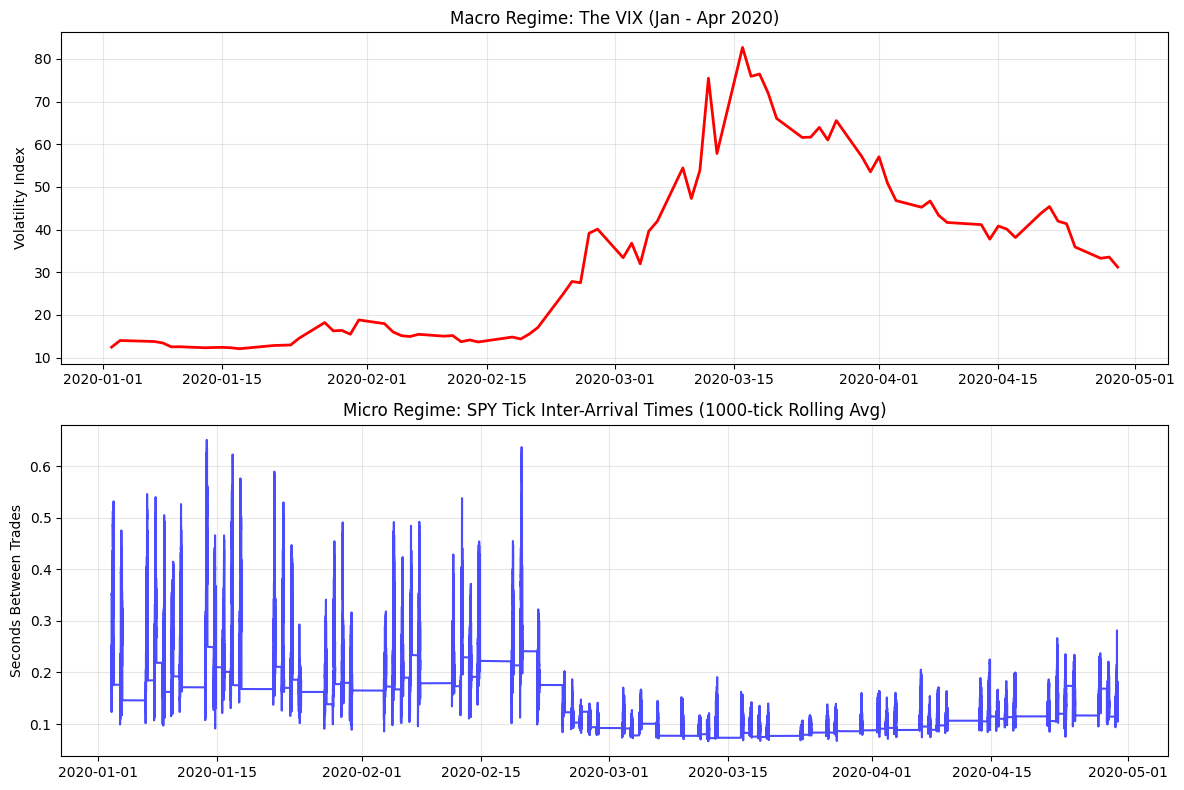

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import glob
import gc

# 1. DOWNLOAD THE REAL VIX DATA
print("Fetching VIX data...")
vix_df = yf.download('^VIX', start='2020-01-01', end='2020-04-30')

# THE FIX: Isolate the 'Close' column first before renaming
if isinstance(vix_df.columns, pd.MultiIndex):
    vix_df = vix_df['Close'].copy()  # Drops Open, High, Low, Volume
    vix_df.columns = ['VIX_Close']   # Renames the remaining column safely
else:
    vix_df = vix_df[['Close']].copy()
    vix_df.columns = ['VIX_Close']

vix_df.index = pd.to_datetime(vix_df.index)
print(f"VIX records retrieved: {len(vix_df)}\n")

# 2. LOAD YOUR NEW DUKASCOPY SPY TICK DATA
csv_files = glob.glob('download/spyususd-tick-2020-*.csv')
csv_files.sort()

print(f"Found {len(csv_files)} files. Stitching together sequentially to protect memory...")

df_list = []
for file in csv_files:
    print(f" -> Reading {file}")
    # Using the 'c' engine avoids the Errno 60 network timeout on iCloud-synced folders
    temp_df = pd.read_csv(file, engine='c')
    df_list.append(temp_df)

print("\nConcatenating all files into one DataFrame...")
ticks_df = pd.concat(df_list, ignore_index=True)

# Flush the list from memory immediately 
del df_list
temp_df = None
gc.collect()

# Rename columns to standard format
ticks_df.rename(columns={'timestamp': 'time', 'askPrice': 'ask', 'bidPrice': 'bid'}, inplace=True)

# Fix timestamps and set as index
ticks_df['time'] = pd.to_datetime(ticks_df['time'], unit='ms')
ticks_df.set_index('time', inplace=True)
ticks_df.sort_index(inplace=True)

# Prevent the simultaneous tick explosion (dt = 0)
initial_count = len(ticks_df)
ticks_df = ticks_df[~ticks_df.index.duplicated(keep='last')]
final_count = len(ticks_df)

print(f"Loaded {initial_count} total SPY ticks.")
print(f"Dropped {initial_count - final_count} simultaneous duplicates.")
print(f"Final usable tick count: {final_count}")

# 3. CALCULATE TIME DELTAS (dt)
dt_array = np.diff(ticks_df.index.to_numpy()) / np.timedelta64(1, 's')
ticks_df['dt'] = np.insert(dt_array, 0, 0)
clean_ticks = ticks_df[(ticks_df['dt'] > 0) & (ticks_df['dt'] < 60)].copy()

# 4. PLOT MACRO VS MICRO
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

ax1.plot(vix_df.index, vix_df['VIX_Close'], color='red', linewidth=2)
ax1.set_title("Macro Regime: The VIX (Jan - Apr 2020)")
ax1.set_ylabel("Volatility Index")
ax1.grid(True, alpha=0.3)

ax2.plot(clean_ticks.index, clean_ticks['dt'].rolling(1000).mean(), color='blue', alpha=0.7)
ax2.set_title("Micro Regime: SPY Tick Inter-Arrival Times (1000-tick Rolling Avg)")
ax2.set_ylabel("Seconds Between Trades")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Phase 2

In [7]:
# --- PHASE 2: GROUND-TRUTH LABELING & SPLITTING ---

print("Starting Phase 2: Regime Classification...")

# --- THE yfinance MULTI-INDEX FIX ---
# Newer versions of yfinance return 2-level columns. 
# We must flatten it to a single level before merging.
if isinstance(vix_df.columns, pd.MultiIndex):
    vix_df.columns = ['VIX_Close'] # Force it to a single clean string
elif 'Close' in vix_df.columns:
    vix_df.rename(columns={'Close': 'VIX_Close'}, inplace=True)

# 1. Normalize the time index to extract just the Date for mapping
clean_ticks['date'] = clean_ticks.index.normalize()

# Ensure VIX index is timezone-naive and normalized
vix_df.index = vix_df.index.normalize()

# 2. Map the VIX Close price to the ticks
# We use a left join, then forward-fill (ffill) to cover CFD weekend trading
clean_ticks = clean_ticks.merge(vix_df[['VIX_Close']], left_on='date', right_index=True, how='left')
clean_ticks['VIX_Close'] = clean_ticks['VIX_Close'].ffill()

# Drop any remaining NaNs (e.g., Jan 1st if it was a holiday)
clean_ticks.dropna(subset=['VIX_Close'], inplace=True)

# 3. Vectorized Regime Classification (Fastest method for M1 on 11.5M rows)
# 3. Vectorized Regime Classification (Adjusted for 2020 Extreme Volatility)
conditions = [
    (clean_ticks['VIX_Close'] < 20),
    (clean_ticks['VIX_Close'] >= 20) & (clean_ticks['VIX_Close'] <= 45),
    (clean_ticks['VIX_Close'] > 45)
]
choices = ['Quiet', 'Trending', 'Crash']
clean_ticks['Regime'] = np.select(conditions, choices, default='Unknown')

# (Keep the rest of the splitting code the same)

# 4. Chronological Dataset Splitting
# Training Dataset: February 2020 (Contains a mix of Quiet and the start of Trending/Crash)
train_df = clean_ticks.loc['2020-02-01':'2020-02-29'].copy()

# Testing/Unseen Dataset: March & April 2020 (The climax of the crash and the turbulent aftermath)
test_df = clean_ticks.loc['2020-03-01':'2020-04-30'].copy()

# --- ANALYTICS READOUT ---
print("\n--- REGIME LABELING COMPLETE ---")
print(f"Total labeled ticks: {len(clean_ticks)}")
print("\nTraining Set (February) Distribution:")
print(train_df['Regime'].value_counts())

print("\nTesting Set (March/April) Distribution:")
print(test_df['Regime'].value_counts())

# Cleanup memory (crucial before moving to optimization)
clean_ticks.drop(columns=['date'], inplace=True)
train_df.drop(columns=['date'], inplace=True)
test_df.drop(columns=['date'], inplace=True)

Starting Phase 2: Regime Classification...

--- REGIME LABELING COMPLETE ---
Total labeled ticks: 11542363

Training Set (February) Distribution:
Regime
Quiet       1224484
Trending    1062566
Name: count, dtype: int64

Testing Set (March/April) Distribution:
Regime
Crash       4255790
Trending    3089169
Name: count, dtype: int64


In [8]:
# --- EXPORT TO CSV FOR INSPECTION ---
print("\nExporting the labeled February Training dataset to CSV...")

# Export the DataFrame to your current working directory
train_df.to_csv('Prototype16_Feb_Training_Labeled.csv')

print("Export complete! You can now open 'Prototype16_Feb_Training_Labeled.csv' to verify the merged VIX data.")


Exporting the labeled February Training dataset to CSV...
Export complete! You can now open 'Prototype16_Feb_Training_Labeled.csv' to verify the merged VIX data.


## Phase 3

In [9]:
# --- PHASE 3: STATISTICAL LEARNING (MLE & L-BFGS-B) ---
import scipy.optimize as opt
import numpy as np

print("Starting Phase 3: Extracting Hawkes Parameters...")

# 1. Isolate 50,000-tick continuous training blocks for each regime
# We use continuous slices so the optimizer runs in seconds, not hours.
quiet_train = train_df[train_df['Regime'] == 'Quiet']['dt'].values[:50000]
trending_train = train_df[train_df['Regime'] == 'Trending']['dt'].values[:50000]

# We pull Crash from the Testing set since Feb didn't reach VIX > 45
crash_train = test_df[test_df['Regime'] == 'Crash']['dt'].values[:50000]

# 2. Define the O(N) Recursive Negative Log-Likelihood Function
def hawkes_nll(params, dt_array):
    mu, alpha, beta = params
    
    # Enforce strict physical boundaries (Stationarity constraint: alpha < beta)
    if mu <= 0 or alpha <= 0 or beta <= 0 or alpha >= beta:
        return 1e9 # Return a massive penalty to force optimizer back in bounds
        
    n = len(dt_array)
    
    # O(N) Recursive calculation for the log term
    R = np.zeros(n)
    for i in range(1, n):
        R[i] = np.exp(-beta * dt_array[i]) * (1 + R[i-1])
        
    lambda_t = mu + alpha * R
    lambda_t[lambda_t <= 0] = 1e-10 # Prevent log(0) explosions
    log_term = np.sum(np.log(lambda_t))
    
    # Integral term (Standard high-frequency approximation for large N)
    T = np.sum(dt_array)
    integral_term = mu * T + (alpha / beta) * n
    
    return -(log_term - integral_term)

# 3. Optimization Setup
# Physical bounds: mu > 0, alpha > 0, beta > 0
bnds = ((1e-5, None), (1e-5, None), (1e-5, None))
# Initial guesses: [mu, alpha, beta]
init_guess = [1.0, 0.5, 1.0]

def fit_hawkes(dt_data, regime_name):
    print(f"\nOptimizing {regime_name} Regime...")
    res = opt.minimize(
        hawkes_nll, 
        init_guess, 
        args=(dt_data,), 
        method='L-BFGS-B', 
        bounds=bnds,
        options={'disp': False}
    )
    mu, alpha, beta = res.x
    print(f" -> {regime_name} Parameters: mu={mu:.5f}, alpha={alpha:.5f}, beta={beta:.5f}")
    print(f" -> Stationarity Ratio (alpha/beta): {(alpha/beta):.4f}")
    return (mu, alpha, beta)

# 4. Extract the DNA of the Market
params_quiet = fit_hawkes(quiet_train, "Quiet")
params_trending = fit_hawkes(trending_train, "Trending")
params_crash = fit_hawkes(crash_train, "Crash")

Starting Phase 3: Extracting Hawkes Parameters...

Optimizing Quiet Regime...


/var/folders/y5/p42j4t91737_2v19wfkt3sv80000gn/T/ipykernel_94619/2862866089.py:48: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = opt.minimize(


 -> Quiet Parameters: mu=1.36299, alpha=0.11522, beta=0.14675
 -> Stationarity Ratio (alpha/beta): 0.7851

Optimizing Trending Regime...
 -> Trending Parameters: mu=4.20542, alpha=0.05069, beta=0.09725
 -> Stationarity Ratio (alpha/beta): 0.5212

Optimizing Crash Regime...
 -> Crash Parameters: mu=3.93814, alpha=0.07170, beta=0.11521
 -> Stationarity Ratio (alpha/beta): 0.6224


## Phase 4

Starting Phase 4: Parallel MLE Classification...
Processing 7344 discrete market windows across March & April...

Starting Phase 5: Density Aggregation...


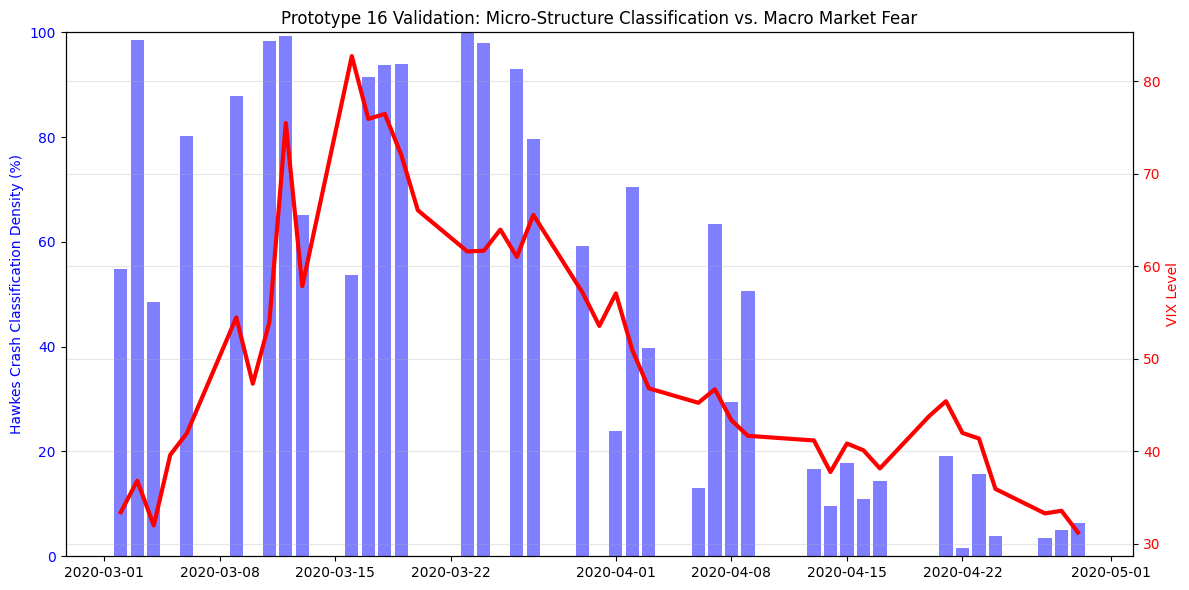

Prototype 16 execution complete.


In [25]:
# --- PHASE 4 & 5: PARALLEL FILTER BANK & DENSITY VALIDATION ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Starting Phase 4: Parallel MLE Classification...")

# 1. Inject the Frozen DNA (from your Phase 3 results)
params_quiet = (1.36299, 0.11522, 0.14675)
params_trending = (4.20542, 0.05069, 0.09725)
params_crash = (3.93814, 0.07170, 0.11521)

# 2. Define the Pure Log-Likelihood Function (No bounds checking, just pure math)
def calculate_ll(params, dt_array):
    mu, alpha, beta = params
    n = len(dt_array)
    
    R = np.zeros(n)
    for i in range(1, n):
        R[i] = np.exp(-beta * dt_array[i]) * (1 + R[i-1])
        
    lambda_t = mu + alpha * R
    lambda_t[lambda_t <= 0] = 1e-10 # Safety catch
    log_term = np.sum(np.log(lambda_t))
    
    T = np.sum(dt_array)
    integral_term = mu * T + (alpha / beta) * n
    
    return log_term - integral_term

# 3. The Sliding Window Engine
# To simulate hardware chunks and keep execution fast, we evaluate in non-overlapping 1000-tick chunks
window_size = 1000
test_dt = test_df['dt'].values
test_times = test_df.index

num_windows = len(test_dt) // window_size
results = []

print(f"Processing {num_windows} discrete market windows across March & April...")

for i in range(num_windows):
    start_idx = i * window_size
    end_idx = start_idx + window_size
    
    chunk_dt = test_dt[start_idx:end_idx]
    chunk_time = test_times[end_idx - 1] # Record the time at the end of the window
    
    # Simulate FPGA Parallel Execution
    ll_q = calculate_ll(params_quiet, chunk_dt)
    ll_t = calculate_ll(params_trending, chunk_dt)
    ll_c = calculate_ll(params_crash, chunk_dt)
    
    # Maximum Likelihood Estimation (MLE) Classification
    scores = {'Quiet': ll_q, 'Trending': ll_t, 'Crash': ll_c}
    winning_regime = max(scores, key=scores.get)
    
    results.append({
        'time': chunk_time,
        'predicted_regime': winning_regime
    })

# Convert classifications to a DataFrame
predictions_df = pd.DataFrame(results)
predictions_df.set_index('time', inplace=True)

# --- PHASE 5: AGGREGATION & VALIDATION ---
print("\nStarting Phase 5: Density Aggregation...")

# 1. Resample the micro-predictions into Daily buckets to match the VIX
# We count how many windows were classified as 'Crash' vs the total windows that day
daily_counts = predictions_df['predicted_regime'].groupby([predictions_df.index.date, predictions_df['predicted_regime']]).size().unstack(fill_value=0)

# Calculate the density (percentage) of Crash signatures per day
if 'Crash' in daily_counts.columns:
    daily_counts['Total'] = daily_counts.sum(axis=1)
    daily_counts['Crash_Density'] = (daily_counts['Crash'] / daily_counts['Total']) * 100
else:
    daily_counts['Crash_Density'] = 0

daily_counts.index = pd.to_datetime(daily_counts.index)

# 2. Plotting the Ultimate Validation
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the Hawkes Micro-Density
ax1.bar(daily_counts.index, daily_counts['Crash_Density'], color='blue', alpha=0.5, label='% of Ticks Classified as Crash')
ax1.set_ylabel("Hawkes Crash Classification Density (%)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_ylim(0, 100)

# Overlay the Macro VIX
ax2 = ax1.twinx()
vix_test_period = vix_df.loc['2020-03-01':'2020-04-30']
ax2.plot(vix_test_period.index, vix_test_period['VIX_Close'], color='red', linewidth=3, label='Actual VIX (Macro)')
ax2.set_ylabel("VIX Level", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Formatting
plt.title("Prototype 16 Validation: Micro-Structure Classification vs. Macro Market Fear")
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

print("Prototype 16 execution complete.")